In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().resolve().parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import perf_counter

from rkhs_epsilon import RKHSEpsilonMachine
from toy_datasets import two_regime_gauss

In [2]:
series, states_true, T_true, pi_true = two_regime_gauss(seed=2137)

In [3]:
def evaluate_configuration(L_past, L_future, clustering_method):
    method_key = clustering_method.lower()
    model_kwargs = dict(
        L_past=L_past,
        L_future=L_future,
        n_components=5,
        regularization=1e-4,
        random_state=2137,
    )

    if method_key == "kmeans":
        model = RKHSEpsilonMachine(
            clustering_method="kmeans",
            **model_kwargs,
        )
    elif method_key == "dbscan":
        model = RKHSEpsilonMachine(
            clustering_method="dbscan",
            **model_kwargs,
        )
    else:
        raise ValueError(f"Unknown clustering method: {clustering_method}")

    try:
        start_time = perf_counter()
        model.fit(series)
        runtime_seconds = perf_counter() - start_time

        comparison = model.compare_to_reference(
            true_states=states_true,
            true_transition_matrix=T_true,
            true_stationary_dist=pi_true,
        )

        mmd_matrix = model.mmd_distance_matrix()
        upper_triangle = mmd_matrix[np.triu_indices_from(mmd_matrix, k=1)]
        mean_pairwise_mmd = float(upper_triangle.mean()) if upper_triangle.size else 0.0

        return {
            "L_past": L_past,
            "L_future": L_future,
            "clustering_method": clustering_method,
            "discovered_states": model.n_states_found_,
            "cluster_accuracy": float(comparison.get("accuracy", np.nan)),
            "transition_matrix_error": float(comparison.get("transition_matrix_error", np.nan)),
            "stationary_distribution_error": float(comparison.get("stationary_distribution_error", np.nan)),
            "statistical_complexity": float(model.statistical_complexity_),
            "entropy_rate": float(model.entropy_rate_),
            "mean_pairwise_mmd": mean_pairwise_mmd,
            "runtime_seconds": runtime_seconds,
            "noise_points": getattr(model, "dbscan_noise_count_", 0),
            "cluster_sizes": model.cluster_sizes_.tolist(),
            "bw_past": float(model.bw_past_),
            "bw_future": float(model.bw_future_),
            "diffusion_eps": float(model.diffusion_eps_),
            "error": None,
        }
    except Exception as exc:
        return {
            "L_past": L_past,
            "L_future": L_future,
            "clustering_method": clustering_method,
            "discovered_states": np.nan,
            "cluster_accuracy": np.nan,
            "transition_matrix_error": np.nan,
            "stationary_distribution_error": np.nan,
            "statistical_complexity": np.nan,
            "entropy_rate": np.nan,
            "mean_pairwise_mmd": np.nan,
            "runtime_seconds": np.nan,
            "noise_points": np.nan,
            "cluster_sizes": None,
            "bw_past": np.nan,
            "bw_future": np.nan,
            "diffusion_eps": np.nan,
            "error": str(exc),
        }

In [4]:
# Parameters to test
# L_past_values = [2, 3, 5, 8, 12, 20]
# L_future_values = [2, 3, 5, 8, 12, 20]
L_past_values = range(2, 101, 2)
L_future_values = range(2, 101, 2)
clustering_methods = ["KMeans", "DBSCAN"]

records = []
for Lp in L_past_values:
    for Lf in L_future_values:
        # print(f"Evaluating: Lp={Lp}, Lf={Lf}...")
        for method in clustering_methods:
            records.append(evaluate_configuration(Lp, Lf, method))

results = pd.DataFrame(records).sort_values(
    ["clustering_method", "L_past", "L_future"]
).reset_index(drop=True)

summary = (
    results.groupby("clustering_method")[[
        "discovered_states",
        "cluster_accuracy",
        "transition_matrix_error",
        "stationary_distribution_error",
        "statistical_complexity",
        "entropy_rate",
        "mean_pairwise_mmd",
        "runtime_seconds",
        "noise_points",
    ]]
    .agg(["mean", "std", "min", "max"])
    .round(4)
)

In [6]:
results.to_csv("cluster_results.csv")

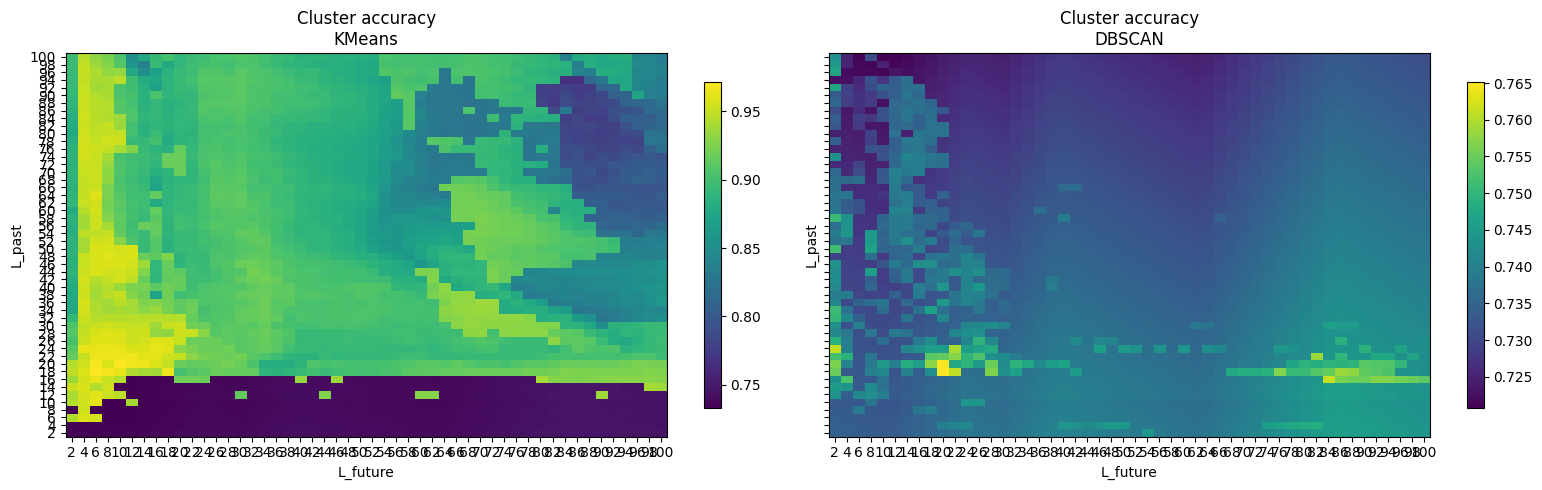

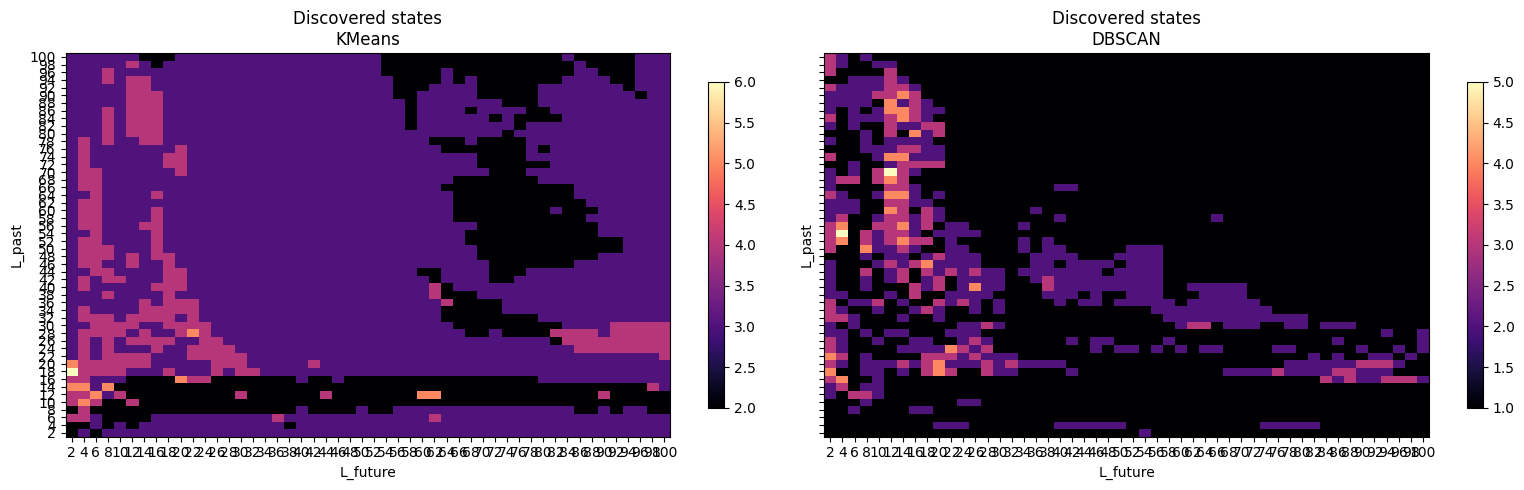

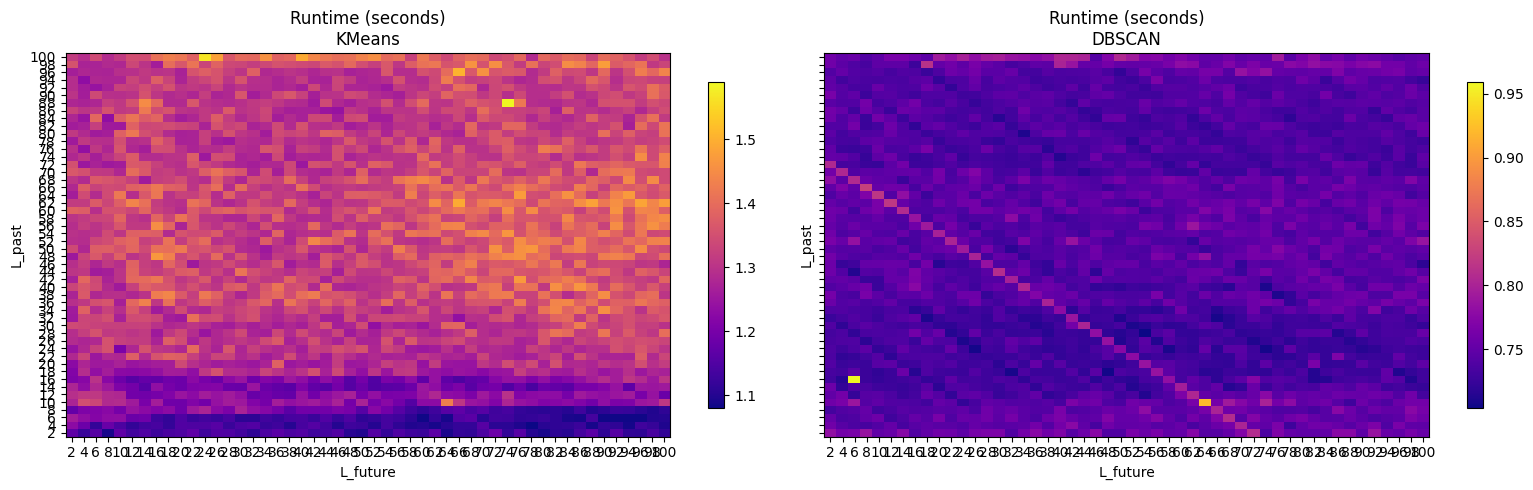

In [5]:
def plot_metric_grid(metric, title, cmap="viridis", value_format="{:.3f}"):
    fig, axes = plt.subplots(1, len(clustering_methods), figsize=(16, 5), sharey=True)
    if len(clustering_methods) == 1:
        axes = [axes]

    for ax, method in zip(axes, clustering_methods):
        pivot = (
            results[results["clustering_method"] == method]
            .pivot(index="L_past", columns="L_future", values=metric)
            .reindex(index=L_past_values, columns=L_future_values)
        )

        data = pivot.to_numpy(dtype=float)
        image = ax.imshow(data, origin="lower", aspect="auto", cmap=cmap)
        ax.set_title(f"{title}\n{method}")
        ax.set_xlabel("L_future")
        ax.set_ylabel("L_past")
        ax.set_xticks(range(len(L_future_values)), labels=L_future_values)
        ax.set_yticks(range(len(L_past_values)), labels=L_past_values)

        finite_values = data[np.isfinite(data)]
        threshold = finite_values.mean() if finite_values.size else 0.0

        # for i, lp in enumerate(L_past_values):
        #     for j, lf in enumerate(L_future_values):
        #         value = pivot.iloc[i, j]
        #         if pd.notna(value):
        #             color = "white" if float(value) >= threshold else "black"
        #             ax.text(j, i, value_format.format(value), ha="center", va="center", color=color, fontsize=8)

        plt.colorbar(image, ax=ax, shrink=0.85)

    plt.tight_layout()
    plt.show()

plot_metric_grid("cluster_accuracy", "Cluster accuracy", cmap="viridis", value_format="{:.3f}")
plot_metric_grid("discovered_states", "Discovered states", cmap="magma", value_format="{:.0f}")
plot_metric_grid("runtime_seconds", "Runtime (seconds)", cmap="plasma", value_format="{:.2f}")